### Poređenje algoritama za preporuku (Two-Tower, Matrix Factorization, Deep Learning)

In [399]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

In [400]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

In [401]:
# Load data
anime = pd.read_csv('data/anime.csv')
ratings = pd.read_csv('data/rating.csv')


In [402]:
print('anime:', anime.shape)

anime: (12294, 7)


In [403]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [404]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [405]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [406]:
anime.dtypes

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

In [407]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [408]:
print('ratings:', ratings.shape)

ratings: (7813737, 3)


In [409]:
ratings.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [410]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [411]:
ratings.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [412]:
ratings.dtypes

user_id     int64
anime_id    int64
rating      int64
dtype: object

In [413]:
ratings.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [414]:
ratings['rating'].value_counts()

rating
 8     1646019
-1     1476496
 7     1375287
 9     1254096
 10     955715
 6      637775
 5      282806
 4      104291
 3       41453
 2       23150
 1       16649
Name: count, dtype: int64

#### Exploratory Data Analysis (EDA)

This section shows basic statistics and plots to understand `ratings` and `anime` distributions, sparsity, and genre information.

In [415]:
sns.set(style='whitegrid')

In [416]:
n_users = ratings['user_id'].nunique()
n_items = anime['anime_id'].nunique()

interactions = len(ratings)
sparsity = 1 - interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {interactions}")
print(f"Sparsity: {sparsity:.6f}")

Users: 73515
Items: 12294
Interactions: 7813737
Sparsity: 0.991355


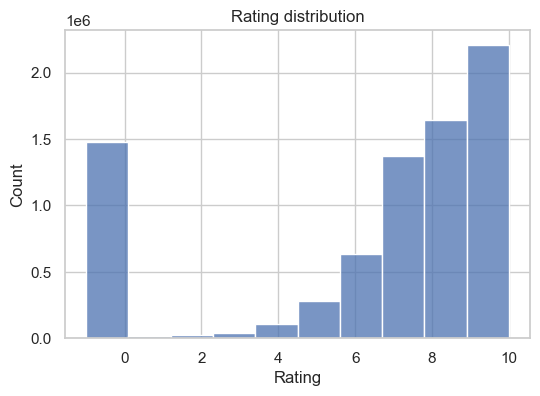

In [417]:
plt.figure(figsize=(6,4))
sns.histplot(ratings['rating'], bins=10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

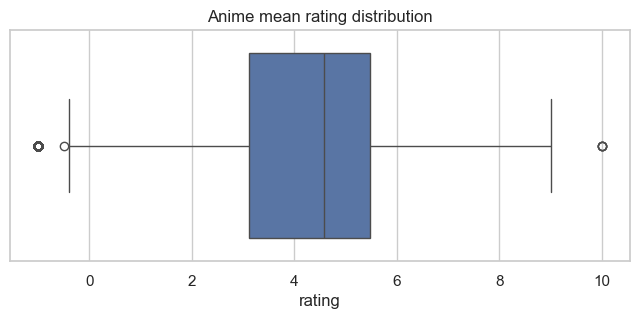

In [418]:
anime_mean = ratings.groupby('anime_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=anime_mean)
plt.title('Anime mean rating distribution')
plt.show()

In [419]:
ratings_work = ratings[ratings["rating"] != -1].copy()

ratings_work.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [420]:
ratings_work.describe()

,user_id,anime_id,rating
count,6.337241e+06,6.337241e+06,6.337241e+06
mean,3.674791e+04,8.902866e+03,7.808497e+00
std,2.101340e+04,8.882000e+03,1.572496e+00
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.898400e+04,1.239000e+03,7.000000e+00
50%,3.681500e+04,6.213000e+03,8.000000e+00
75%,5.487300e+04,1.407500e+04,9.000000e+00
max,7.351600e+04,3.447500e+04,1.000000e+01


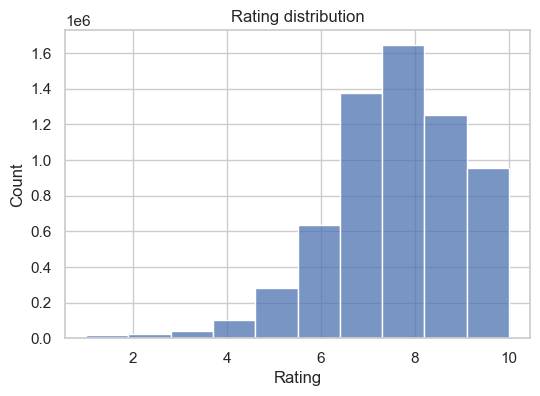

In [421]:
plt.figure(figsize=(6,4))
sns.histplot(ratings_work['rating'], bins=10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

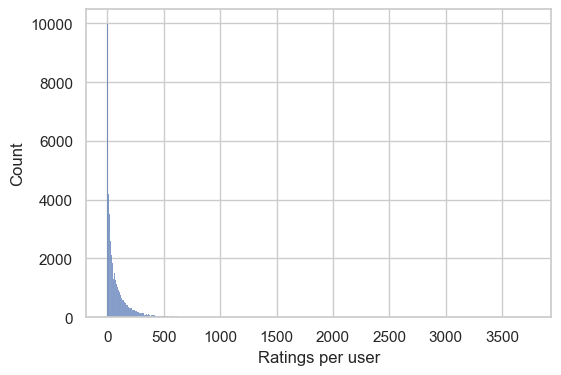

In [422]:
user_counts = ratings_work.groupby('user_id').size()

plt.figure(figsize=(6,4))
sns.histplot(user_counts)
plt.xlabel('Ratings per user')
plt.show()

/var/folders/82/h_3rsy994nq910bxmgv6kh680000gn/T/ipykernel_76281/3760345753.py:12: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


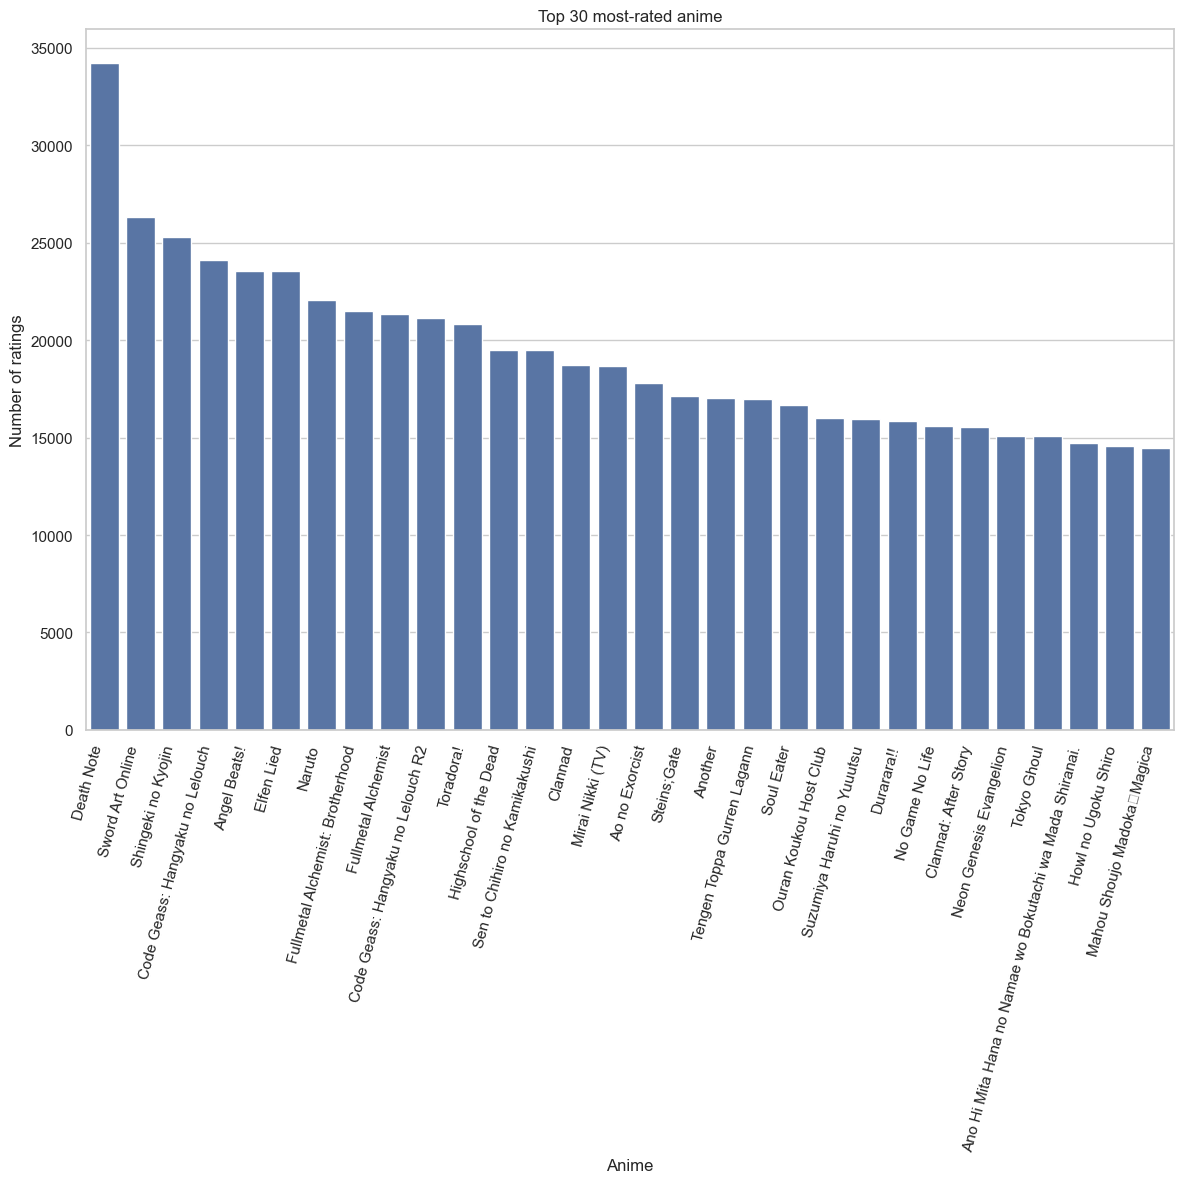

In [423]:

item_counts = ratings_work.groupby('anime_id').size().sort_values(ascending=False)
top30 = item_counts.head(30).reset_index().merge(anime[['anime_id','name']], on='anime_id', how='left')



plt.figure(figsize=(12,12))
sns.barplot(x='name', y=0, data=top30)
plt.xticks(rotation=75, ha='right')
plt.title('Top 30 most-rated anime')
plt.ylabel('Number of ratings')
plt.xlabel('Anime')
plt.tight_layout()
plt.show()

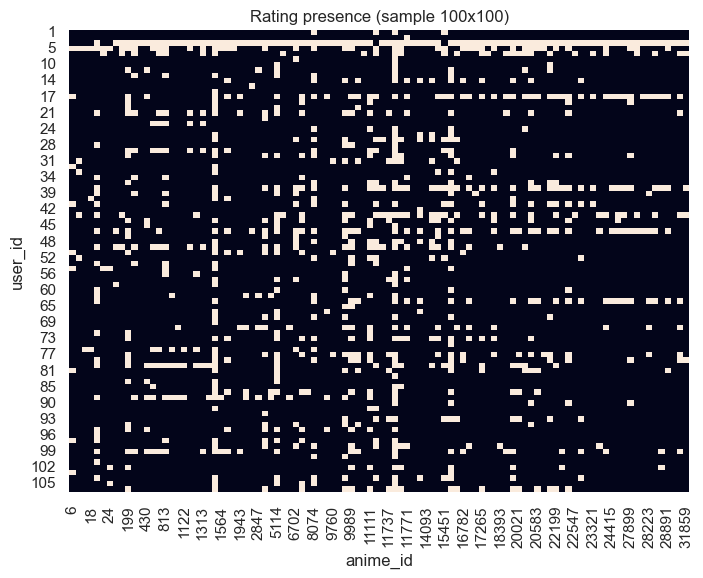

In [424]:
sample_users = ratings_work['user_id'].unique()[:100]
sample_items = ratings_work['anime_id'].unique()[:100]

sample = ratings_work[ratings_work['user_id'].isin(sample_users) & ratings_work['anime_id'].isin(sample_items)]
pivot = sample.pivot_table(index='user_id', columns='anime_id', values='rating')

plt.figure(figsize=(8,6))
sns.heatmap(pivot.notna(), cbar=False)
plt.title('Rating presence (sample 100x100)')
plt.show()

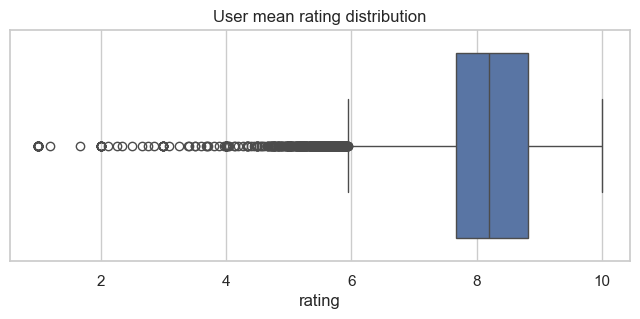

In [425]:
user_mean = ratings_work.groupby('user_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=user_mean)
plt.title('User mean rating distribution')
plt.show()

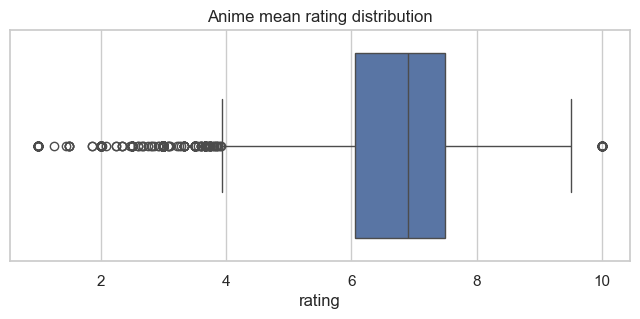

In [426]:

anime_mean = ratings_work.groupby('anime_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=anime_mean)
plt.title('Anime mean rating distribution')
plt.show()

In [427]:
n_users = ratings_work['user_id'].nunique()
n_items = anime['anime_id'].nunique()

interactions = len(ratings_work)
sparsity = 1 - interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {interactions}")
print(f"Sparsity: {sparsity:.6f}")

Users: 69600
Items: 12294
Interactions: 6337241
Sparsity: 0.992594


<Axes: ylabel='Count'>

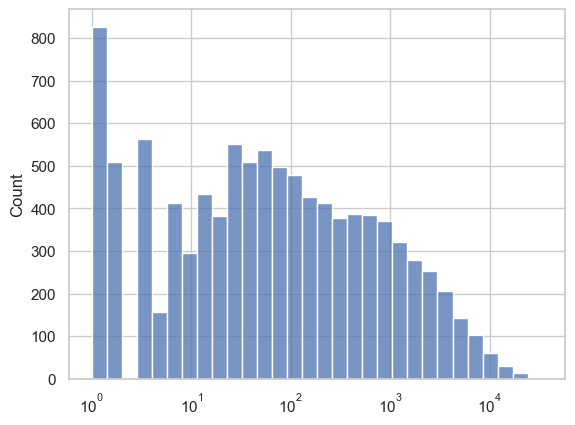

In [428]:
sns.histplot(item_counts, log_scale=True)

In [429]:
(user_counts < 5)

user_id
1         True
2         True
3        False
5        False
7        False
         ...  
73512    False
73513    False
73514     True
73515    False
73516     True
Length: 69600, dtype: bool

### Data Preprocessing

Filter low-activity users and rare items, create ID mappings, and split into train/test sets for model evaluation.

In [430]:
MIN_USER_POS = 5
MIN_ITEM_POS = 20   
POS_THRESHOLD = 7

In [431]:
ratings_work["interaction"] = (ratings_work["rating"] >= POS_THRESHOLD).astype(int)

ratings_pos = ratings_work[ratings_work["interaction"] == 1][["user_id", "anime_id"]].drop_duplicates()

print("Positive interactions:", len(ratings_pos))
ratings_pos.head()


Positive interactions: 5231113


,user_id,anime_id
47,1,8074
81,1,11617
83,1,11757
101,1,15451
153,2,11771


In [432]:
user_pos_counts = ratings_pos["user_id"].value_counts()
valid_users = user_pos_counts[user_pos_counts >= MIN_USER_POS].index

valid_users

Index([57620, 45659, 65840, 59643, 42635, 28196,  9032, 11536, 53698, 51270,
       ...
       60768, 35751, 57101, 30112, 36825,  8207, 50938, 62596, 58292, 28373],
      dtype='int64', name='user_id', length=60384)

In [433]:
ratings_filtered = ratings_pos[ratings_pos["user_id"].isin(valid_users)].copy()

ratings_filtered.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5211321 entries, 156 to 7813734
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
dtypes: int64(2)
memory usage: 119.3 MB


In [434]:
item_pos_counts = ratings_filtered["anime_id"].value_counts()
valid_items = item_pos_counts[item_pos_counts >= MIN_ITEM_POS].index

valid_items

Index([ 1535, 16498,  1575, 11757,  6547,  5114,  2904,   226,   121,  4224,
       ...
        3120,  2540,  1100,  2912,  4701, 30128,  2622,  4908,  1031, 28157],
      dtype='int64', name='anime_id', length=5609)

In [435]:
ratings_filtered = ratings_filtered[ratings_filtered["anime_id"].isin(valid_items)]

ratings_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5190808 entries, 156 to 7813734
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
dtypes: int64(2)
memory usage: 118.8 MB


In [436]:
print(f"Original ratings rows: {len(ratings)}")
print(f"Filtered positive interactions: {len(ratings_filtered)}")

print(f"Users kept: {ratings_filtered['user_id'].nunique()} (min positives: {MIN_USER_POS})")
print(f"Items kept: {ratings_filtered['anime_id'].nunique()} (min positives: {MIN_ITEM_POS})")


Original ratings rows: 7813737
Filtered positive interactions: 5190808
Users kept: 60384 (min positives: 5)
Items kept: 5609 (min positives: 20)


In [437]:

user_enc = LabelEncoder()
item_enc = LabelEncoder()

ratings_filtered["user_idx"] = user_enc.fit_transform(ratings_filtered["user_id"]).astype(int)
ratings_filtered["item_idx"] = item_enc.fit_transform(ratings_filtered["anime_id"]).astype(int)

# reverse map: item_idx -> anime_id (guaranteed for every item_idx)
idx2item = {int(i): int(aid) for i, aid in enumerate(item_enc.classes_)}

# (optional) reverse for users too
idx2user = {int(i): int(uid) for i, uid in enumerate(user_enc.classes_)}

n_users = ratings_filtered["user_idx"].nunique()
n_items = ratings_filtered["item_idx"].nunique()

print("Dense mapping done.")
print("n_users:", n_users, "n_items:", n_items)
print("max item_idx:", int(ratings_filtered["item_idx"].max()))


Dense mapping done.
n_users: 60384 n_items: 5609
max item_idx: 5608


In [438]:
n_interactions = len(ratings_filtered)

sparsity_clean = 1 - n_interactions / (n_users * n_items)

print("Clean sparsity:", sparsity_clean)

Clean sparsity: 0.9846740414446726


In [439]:
# # Train/test split (Per-user holdout: 1 test item per user)

# train_list = []
# test_list = []

# for uid, group in ratings_filtered.groupby("user_idx"):
#     if len(group) < 2:
#         continue

#     test_sample = group.sample(1, random_state=42)
#     train_sample = group.drop(test_sample.index)

#     train_list.append(train_sample)
#     test_list.append(test_sample)

# train_df = pd.concat(train_list).reset_index(drop=True)
# test_df = pd.concat(test_list).reset_index(drop=True)

test_df = ratings_filtered.groupby("user_idx").sample(
    n=1,
    random_state=42
)

train_df = ratings_filtered.drop(test_df.index)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)



In [440]:
print("Per-user holdout split:")
print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))

Per-user holdout split:
Train interactions: 5130424
Test interactions: 60384


In [441]:
print("Users in train:", train_df["user_idx"].nunique())
print("Users in test:", test_df["user_idx"].nunique())

Users in train: 60384
Users in test: 60384


In [442]:

assert train_df.merge(test_df, on=["user_idx", "item_idx"]).empty
print("No overlap between train and test")

No overlap between train and test


In [443]:
train_user_items = (
    train_df.groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

test_user_item = (
    test_df.groupby("user_idx")["item_idx"]
    .first()
    .to_dict()
)

print("Users in train_user_items:", len(train_user_items))
print("Users in test_user_item:", len(test_user_item))


Users in train_user_items: 60384
Users in test_user_item: 60384


### Recommendation Models

Comparison of three recommendation algorithms on the anime ratings dataset.

#### 1. Matrix Factorization

In [444]:
user_item_mat = sp.csr_matrix(
    (
        np.ones(len(train_df), dtype=np.float32),
        (train_df["user_idx"].to_numpy(), train_df["item_idx"].to_numpy()),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

print("user_item_mat:", user_item_mat.shape, "nnz:", user_item_mat.nnz)


user_item_mat: (60384, 5609) nnz: 5130424


In [445]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    random_state=42,
    num_threads=1,
)

alpha = 40.0
# Fit on user->item matrix; implicit ALS expects users as rows, items as columns
user_item_conf = (user_item_mat * alpha).tocsr()

als_model.fit(user_item_conf)

# Sanity checks: item_factors must match n_items, user_factors must match n_users
assert als_model.item_factors.shape[0] == n_items
assert als_model.user_factors.shape[0] == n_users

print("ALS training complete.")


  0%|          | 0/15 [00:00<?, ?it/s]

ALS training complete.


In [446]:
print("ALS user_factors shape:", als_model.user_factors.shape)
print("ALS item_factors shape:", als_model.item_factors.shape)

print("max user_idx in train_df:", train_df["user_idx"].max())
print("max user_idx in test_df :", test_df["user_idx"].max())
print("max user_idx in ratings_filtered:", ratings_filtered["user_idx"].max())


ALS user_factors shape: (60384, 64)
ALS item_factors shape: (5609, 64)
max user_idx in train_df: 60383
max user_idx in test_df : 60383
max user_idx in ratings_filtered: 60383


In [447]:
def als_score_fn(u, item_candidates):
    user_vec = als_model.user_factors[int(u)]
    item_vecs = als_model.item_factors[item_candidates]
    return item_vecs @ user_vec


In [448]:
def ndcg_at_k(rank, k):
    if rank is None or rank > k:
        return 0.0
    return 1.0 / np.log2(rank + 1)

In [449]:
def evaluate_sampled_topk(score_fn, test_user_item, train_user_items, num_items, k=10, num_neg=200, seed=42):
    rng = np.random.default_rng(seed)
    recalls = np.empty(len(test_user_item), dtype=np.float32)
    ndcgs = np.empty(len(test_user_item), dtype=np.float32)

    for idx, (u, true_i) in enumerate(test_user_item.items()):
        u = int(u)
        true_i = int(true_i)
        seen = train_user_items.get(u, set())

        negs = set()
        while len(negs) < num_neg:
            cand = int(rng.integers(0, num_items))
            if cand != true_i and cand not in seen:
                negs.add(cand)

        candidates = np.empty(1 + num_neg, dtype=np.int32)
        candidates[0] = true_i
        candidates[1:] = np.fromiter(negs, dtype=np.int32, count=num_neg)

        scores = score_fn(u, candidates)

        order = np.argsort(-scores)
        ranked = candidates[order]

        topk = ranked[:k]
        hit = np.any(topk == true_i)
        recalls[idx] = 1.0 if hit else 0.0

        true_rank = int(np.where(ranked == true_i)[0][0]) + 1
        ndcgs[idx] = ndcg_at_k(true_rank, k)

    return float(recalls.mean()), float(ndcgs.mean())


In [ ]:
max_u_allowed = als_model.user_factors.shape[0] - 1
max_i_allowed = als_model.item_factors.shape[0] - 1

train_user_items = {u: items for u, items in train_user_items.items() if u <= max_u_allowed}
test_user_item   = {u: i for u, i in test_user_item.items() if u <= max_u_allowed and i <= max_i_allowed}

print("Users in test after ALS-range filter:", len(test_user_item))


Users in test after ALS-range filter: 60384
Max test user: 60383


In [451]:
rec10, ndcg10 = evaluate_sampled_topk(
    als_score_fn,
    test_user_item=test_user_item,
    train_user_items=train_user_items,
    num_items=n_items,
    k=10,
    num_neg=200
)

print(f"ALS MF -> Recall@10: {rec10:.4f}, NDCG@10: {ndcg10:.4f}")


ALS MF -> Recall@10: 0.8431, NDCG@10: 0.5918


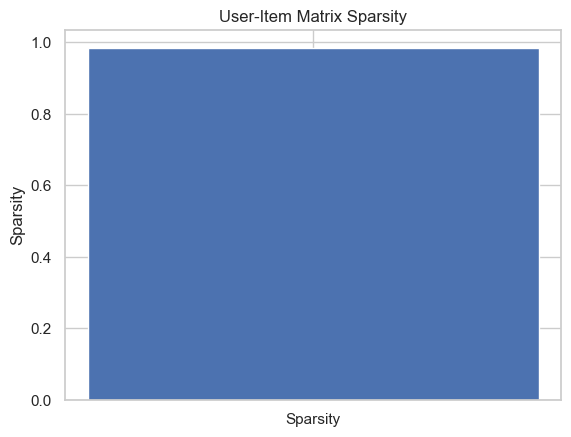

Sparsity: 0.9846740414446726


In [452]:
sparsity = 1 - (len(ratings_filtered) / (n_users * n_items))

plt.figure()
plt.bar(["Sparsity"], [sparsity])
plt.title("User-Item Matrix Sparsity")
plt.ylabel("Sparsity")
plt.show()

print("Sparsity:", sparsity)

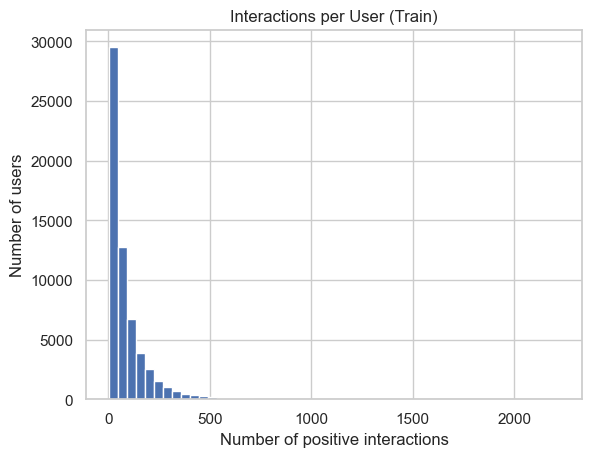

In [453]:
user_counts = train_df["user_idx"].value_counts()

plt.figure()
plt.hist(user_counts, bins=50)
plt.title("Interactions per User (Train)")
plt.xlabel("Number of positive interactions")
plt.ylabel("Number of users")
plt.show()

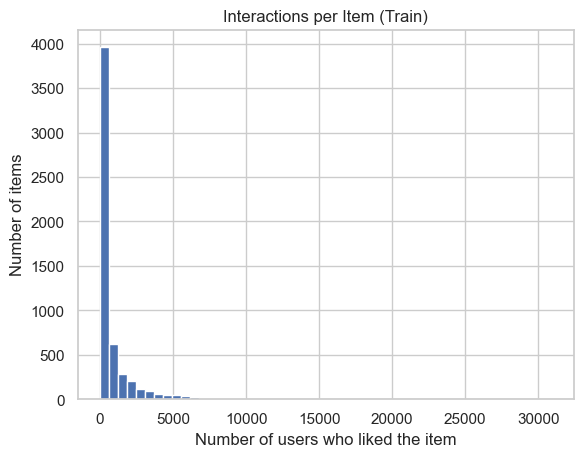

In [454]:
item_counts = train_df["item_idx"].value_counts()

plt.figure()
plt.hist(item_counts, bins=50)
plt.title("Interactions per Item (Train)")
plt.xlabel("Number of users who liked the item")
plt.ylabel("Number of items")
plt.show()

In [455]:
anime_clean = anime.copy()

anime_clean["anime_id"] = anime_clean["anime_id"].astype(int)

anime_clean = anime_clean.dropna(subset=["name"])

anime_name_map = dict(zip(anime_clean["anime_id"], anime_clean["name"]))

print("anime_name_map size:", len(anime_name_map))
print("example:", list(anime_name_map.items())[:3])

anime_name_map size: 12294
example: [(32281, 'Kimi no Na wa.'), (5114, 'Fullmetal Alchemist: Brotherhood'), (28977, 'Gintama°')]


In [459]:
sample_user = list(test_user_item.keys())[0]

recs = als_model.recommend(
    userid=sample_user,
    user_items=user_item_mat[sample_user],  
    N=10,
    filter_already_liked_items=True
)

print("True test item_idx:", int(test_user_item[sample_user]))


true_item = test_user_item[sample_user]
true_anime_id = idx2item[int(true_item)]
true_title = anime_name_map.get(true_anime_id, "Unknown")

print("\nTrue test anime:")
print(f"{true_title} (anime_id={true_anime_id})")


True test item_idx: 393

True test anime:
Fullmetal Alchemist: The Conqueror of Shamballa (anime_id=430)


In [458]:
item_ids, scores = recs

print("\nTop-10 recommendations:")

for rank, (x, score) in enumerate(zip(item_ids, scores), 1):
    x = int(x)
    anime_id = idx2item[x] if x in idx2item else x
    title = anime_name_map.get(anime_id, "Unknown")
    print(f"{rank}. {title} (anime_id={anime_id}, score={float(score):.3f})")


item_ids, scores = recs



Top-10 recommendations:
1. Hunter x Hunter (2011) (anime_id=11061, score=1.197)
2. One Punch Man (anime_id=30276, score=1.144)
3. Shaman King (anime_id=154, score=1.132)
4. Kiseijuu: Sei no Kakuritsu (anime_id=22535, score=1.109)
5. Tokyo Ghoul (anime_id=22319, score=1.097)
6. Zankyou no Terror (anime_id=23283, score=1.086)
7. Bakuman. (anime_id=7674, score=1.081)
8. Bakuman. 3rd Season (anime_id=12365, score=1.068)
9. Psycho-Pass (anime_id=13601, score=1.066)
10. Death Parade (anime_id=28223, score=1.057)


#### 2. Two-Tower Model

#### 3. Deep learning